# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

There are two reasons to add a penalty to MSE that grows based on model parameter size. You aim to create a model that learns to be more efficient (accuracy per parameter) as well as punish the model for overfitting. Without a penalty, the model will have much higher variance as well as the OLS minizmizes bias but introduces high variance in the coefficients, so we accept a small bias to reduce that variance and improve generalization.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization gives you a way of tuning to see how the model's variance and bias change as lamba changes, which allows you to optimize lambda based on the bias-variance output. So you find a point in between 0 and infinity where bias and variance is minimized. It's like a tuner you can use.


3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Both LASSO and Ridge add a penalty to OLS but the shape of the penatly is different. for Ridge, the penalty minimizes the coefficients close to zero, but never exactly while with LASSO, the coefficients can be minized to zero. The answers change depending on if the true model is sparse or dense where if it's sparse Ridge will likely have better results while if they are more dense, then LASSO will win out.


4. How do we typically scale variables for use in regularized regression? Why?

We standardize each predictor to have mean = zero and standard deviation = one. We do this to make sure that the penatly is applied equally to our coefficients and model because if we have a coefficient measured in millions and one measured in thousands, the one in thousands will not have much changed from the penatly while the one in millions can have so much more changed even if in practice it doesn't need as strong of a penalty.


5. How is the penalty $\alpha$ typically selected?

Cross-validation. For each candidate, we run k-fold cross-validation: split the data into k folds, train on k-1 folds, predict on the held-out fold, and record the prediction error.


6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No, we evaluate the held-out fold using regular MSE. We do this because the penalty and predction error serve different purposes. The penalty constrains how the model fits the data.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [1]:
! git clone https://github.com/asomers205/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 118 (delta 42), reused 31 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (118/118), 1.76 MiB | 8.81 MiB/s, done.
Resolving deltas: 100% (55/55), done.
Download complete
Extracting data files...
Data extracted


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


Polynomial features: ['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']

--- Linear Regression Coefficients ---
Mileage_Run          7.861191e+05
Age                 -2.141229e+05
Mileage_Run^2       -1.783803e+05
Mileage_Run Age     -1.453125e+06
Age^2                2.789820e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    3.109725e+05
Mileage_Run Age^2    6.186680e+05
Age^3               -1.724494e+05

Sign of Mileage_Run × Age interaction: negative (-1453124.9641)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 13281481185.15625, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 195023282225.625, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 671011860110.5, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective 


Optimal alpha: 143.8450


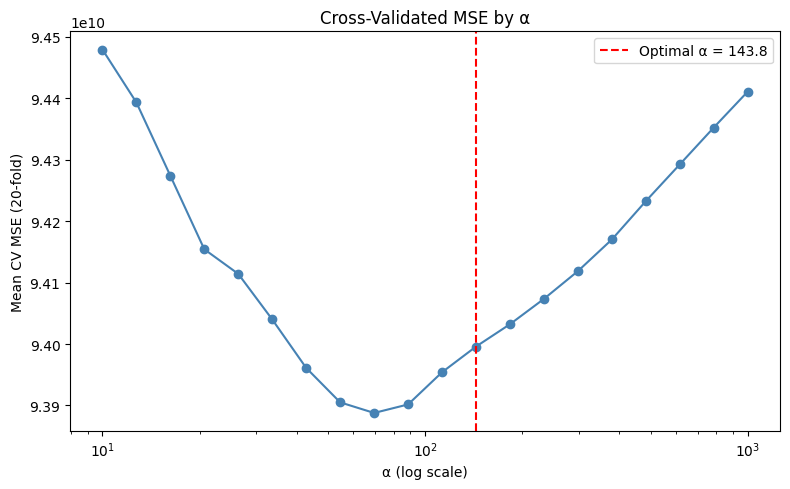

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.144e+12, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.615e+12, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.230e+12, tolerance: 1.316e

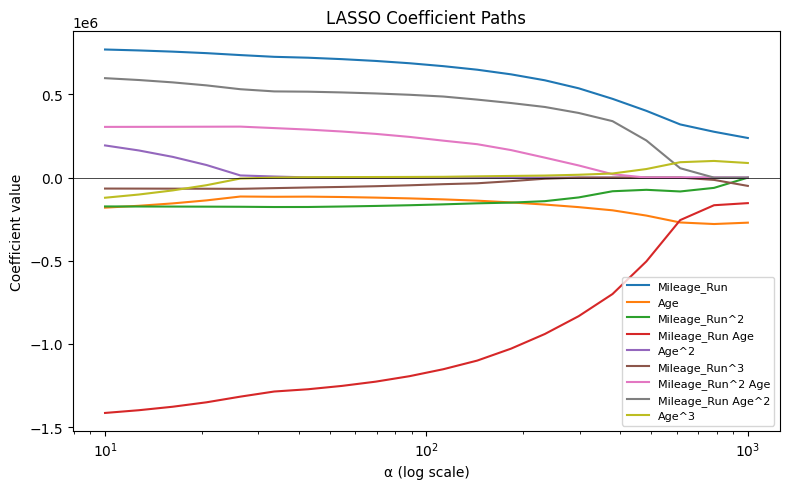


--- LASSO Coefficients (optimal α) ---
Mileage_Run          590420.344996
Age                 -310779.019923
Mileage_Run^2       -433799.302553
Mileage_Run Age     -563273.951376
Age^2                130525.441246
Mileage_Run^3         56444.270689
Mileage_Run^2 Age    315528.244311
Mileage_Run Age^2     29005.706242
Age^3                 64855.798834

Selected features (9/9):
Mileage_Run          590420.344996
Age                 -310779.019923
Mileage_Run^2       -433799.302553
Mileage_Run Age     -563273.951376
Age^2                130525.441246
Mileage_Run^3         56444.270689
Mileage_Run^2 Age    315528.244311
Mileage_Run Age^2     29005.706242
Age^3                 64855.798834

Proportion set to zero: 0/9 = 0.00%

--- Coefficient Comparison ---
                            OLS          LASSO  Δ (LASSO − OLS)
Mileage_Run        7.861191e+05  590420.344996   -195698.718042
Age               -2.141229e+05 -310779.019923    -96656.099755
Mileage_Run^2     -1.783803e+05 -433799.302

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV

# ==============================================================================
# 1. Import data, create Age, polynomial expansion + standardization
# ==============================================================================

df = pd.read_csv('./data/cars_hw.csv')
display(df.head())

# Create Age (adjust the reference year if needed)
df["Age"] = 2025 - df["Make_Year"]

# Grab the two raw features
X_raw = df[["Mileage_Run", "Age"]]

# (a) Third-degree polynomial expansion (includes interaction terms)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_raw)
feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])
print("Polynomial features:", feature_names)

# (b) Z-score normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Target variable — adjust column name to match your file
y = df["Price"]

# ==============================================================================
# 2. Linear regression — sign of the Mileage_Run × Age interaction
# ==============================================================================

lr = LinearRegression()
lr.fit(X_scaled, y)

lr_coefs = pd.Series(lr.coef_, index=feature_names)
print("\n--- Linear Regression Coefficients ---")
print(lr_coefs.to_string())

interaction_term = "Mileage_Run Age"  # name generated by PolynomialFeatures
print(f"\nSign of Mileage_Run × Age interaction: "
      f"{'positive' if lr_coefs[interaction_term] > 0 else 'negative'} "
      f"({lr_coefs[interaction_term]:.4f})")

# ==============================================================================
# 3. LassoCV — 20-fold CV with log-spaced alpha grid
# ==============================================================================

alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas, cv=20, random_state=42)
lasso_cv.fit(X_scaled, y)

print(f"\nOptimal alpha: {lasso_cv.alpha_:.4f}")

# ==============================================================================
# 4. Plot cross-validated MSE by alpha
# ==============================================================================

mean_mse = lasso_cv.mse_path_.mean(axis=1)   # shape: (n_alphas,)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alphas, mean_mse, "o-", color="steelblue")
ax.axvline(lasso_cv.alpha_, color="red", linestyle="--", label=f"Optimal α = {lasso_cv.alpha_:.1f}")
ax.set_xscale("log")
ax.set_xlabel("α (log scale)")
ax.set_ylabel("Mean CV MSE (20-fold)")
ax.set_title("Cross-Validated MSE by α")
ax.legend()
plt.tight_layout()
plt.savefig("mse_by_alpha.png", dpi=150)
plt.show()

# ==============================================================================
# 5. Plot coefficient paths by alpha
# ==============================================================================

coef_paths = []
for a in alphas:
    from sklearn.linear_model import Lasso
    model = Lasso(alpha=a, max_iter=10000)
    model.fit(X_scaled, y)
    coef_paths.append(model.coef_)
coef_paths = np.array(coef_paths)  # shape: (n_alphas, n_features)

fig, ax = plt.subplots(figsize=(8, 5))
for j, name in enumerate(feature_names):
    ax.plot(alphas, coef_paths[:, j], label=name)
ax.set_xscale("log")
ax.set_xlabel("α (log scale)")
ax.set_ylabel("Coefficient value")
ax.set_title("LASSO Coefficient Paths")
ax.legend(fontsize=8, loc="best")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig("coefficient_paths.png", dpi=150)
plt.show()

# ==============================================================================
# 6. Which features are selected? Proportion zeroed out?
# ==============================================================================

lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)
print("\n--- LASSO Coefficients (optimal α) ---")
print(lasso_coefs.to_string())

selected = lasso_coefs[lasso_coefs != 0]
zeroed   = lasso_coefs[lasso_coefs == 0]

print(f"\nSelected features ({len(selected)}/{len(feature_names)}):")
print(selected.to_string())
print(f"\nProportion set to zero: {len(zeroed)}/{len(feature_names)} "
      f"= {len(zeroed)/len(feature_names):.2%}")

# ==============================================================================
# 7. Compare OLS vs LASSO coefficients
# ==============================================================================

comparison = pd.DataFrame({
    "OLS":   lr_coefs,
    "LASSO": lasso_coefs,
    "Δ (LASSO − OLS)": lasso_coefs - lr_coefs
})
print("\n--- Coefficient Comparison ---")
print(comparison.to_string())

# Coefficients that increased in magnitude
increased = comparison[abs(comparison["LASSO"]) > abs(comparison["OLS"])]
print(f"\nCoefficients that INCREASED in magnitude: "
      f"{list(increased.index) if len(increased) else 'None'}")

# Coefficients that changed sign
sign_change = comparison[
    (comparison["OLS"] * comparison["LASSO"] < 0) & (comparison["LASSO"] != 0)
]
print(f"Coefficients that CHANGED sign: "
      f"{list(sign_change.index) if len(sign_change) else 'None'}")

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']
(299, 13)
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.

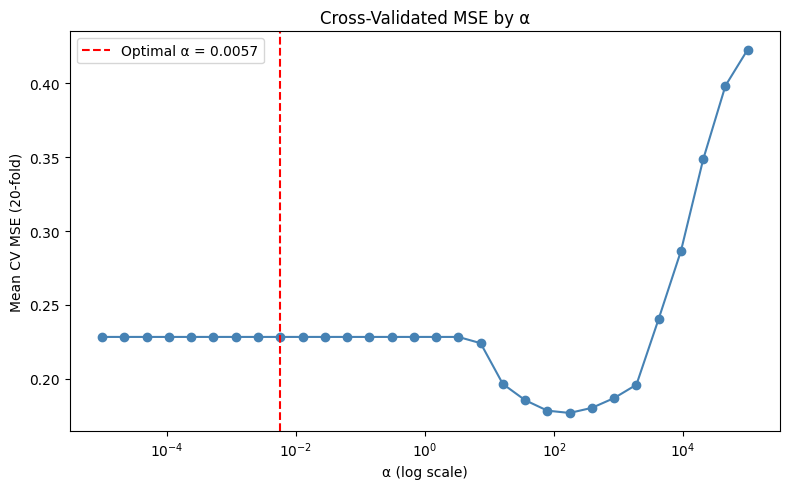

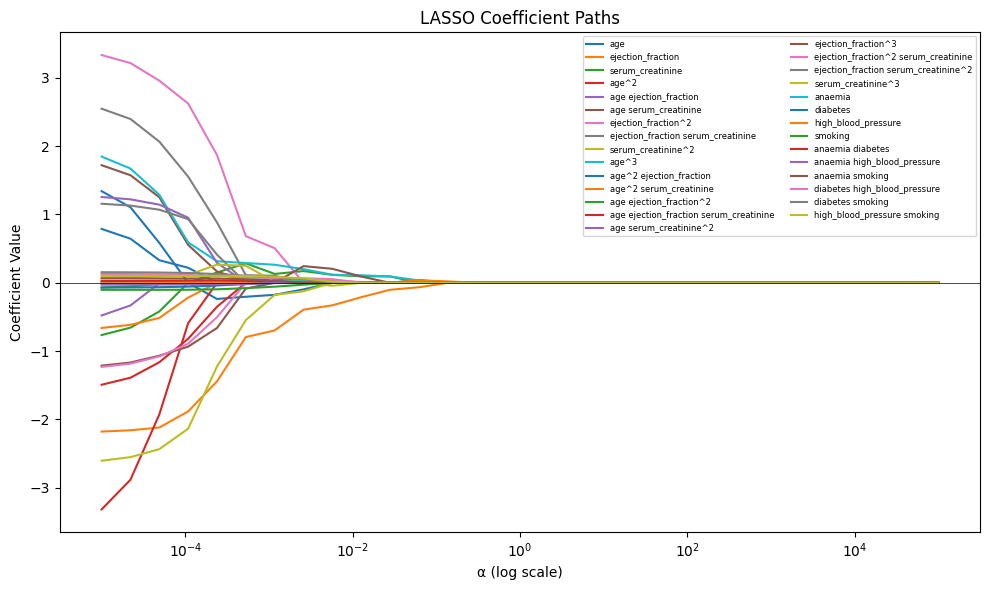

--- LASSO Coefficients (optimal α) ---
age                                      -0.000000
ejection_fraction                        -0.329656
serum_creatinine                          0.116875
age^2                                     0.000000
age ejection_fraction                    -0.000000
age serum_creatinine                      0.000000
ejection_fraction^2                       0.000000
ejection_fraction serum_creatinine        0.000000
serum_creatinine^2                       -0.000000
age^3                                     0.117992
age^2 ejection_fraction                   0.000000
age^2 serum_creatinine                    0.000000
age ejection_fraction^2                   0.000000
age ejection_fraction serum_creatinine    0.000000
age serum_creatinine^2                   -0.000000
ejection_fraction^3                       0.204822
ejection_fraction^2 serum_creatinine      0.032801
ejection_fraction serum_creatinine^2     -0.000000
serum_creatinine^3                       -0

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, LassoCV


df = pd.read_csv("./data/heart_failure_clinical_records_dataset.csv")
print(df.columns.tolist())
print(df.shape)
print(df.head())

# Q1: Build feature matrix

# --- Continuous features: 3rd-degree polynomial expansion + standardize ---
continuous = df[["age", "ejection_fraction", "serum_creatinine"]]

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(continuous)
cont_names = poly_cont.get_feature_names_out(["age", "ejection_fraction", "serum_creatinine"])

scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

print(f"Continuous polynomial features ({len(cont_names)}):")
print(cont_names)

# --- Categorical features: interactions only ---
dummies = df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

poly_cat = PolynomialFeatures(interaction_only=True, include_bias=False)
X_cat_poly = poly_cat.fit_transform(dummies)
cat_names = poly_cat.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"])

print(f"\nCategorical interaction features ({len(cat_names)}):")
print(cat_names)

# --- Concatenate ---
X = np.concatenate([X_cont_scaled, X_cat_poly], axis=1)
feature_names = np.concatenate([cont_names, cat_names])
print(f"\nTotal features: {len(feature_names)}")

# Target: DEATH_EVENT
y = df["DEATH_EVENT"]

# Q2: Linear regression
lr = LinearRegression().fit(X, y)
lr_coefs = pd.Series(lr.coef_, index=feature_names)

print("--- OLS Coefficients ---")
print(lr_coefs.to_string())
print(f"\nIntercept: {lr.intercept_:.4f}")

# Flag potentially counterintuitive signs
print("\n--- Sign check on key linear terms ---")
for feat in ["age", "ejection_fraction", "serum_creatinine",
             "anaemia", "diabetes", "high_blood_pressure", "smoking"]:
    if feat in lr_coefs.index:
        sign = "+" if lr_coefs[feat] > 0 else "-"
        print(f"  {feat}: {sign} ({lr_coefs[feat]:.6f})")

# Q3: LassoCV with 20-fold CV
# NOTE: The hint says np.logspace(5,5,30) which produces a single repeated
# value. This is almost certainly meant to be np.logspace(-5,5,30).
alphas = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000, random_state=42)
lasso_cv.fit(X, y)

print(f"Optimal alpha: {lasso_cv.alpha_:.6f}")

# Q4: Plot CV MSE by alpha
mean_mse = lasso_cv.mse_path_.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(alphas, mean_mse, "o-", color="steelblue")
plt.axvline(lasso_cv.alpha_, color="red", linestyle="--",
            label=f"Optimal α = {lasso_cv.alpha_:.4f}")
plt.xscale("log")
plt.xlabel("α (log scale)")
plt.ylabel("Mean CV MSE (20-fold)")
plt.title("Cross-Validated MSE by α")
plt.legend()
plt.tight_layout()
plt.show()

# Q5: Coefficient paths by alpha
coef_paths = []
for a in alphas:
    model = Lasso(alpha=a, max_iter=100000)
    model.fit(X, y)
    coef_paths.append(model.coef_)
coef_paths = np.array(coef_paths)

plt.figure(figsize=(10, 6))
for j, name in enumerate(feature_names):
    plt.plot(alphas, coef_paths[:, j], label=name)
plt.xscale("log")
plt.xlabel("α (log scale)")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths")
plt.legend(fontsize=6, loc="best", ncol=2)
plt.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

# Q6: Feature selection & comparison

lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

selected = lasso_coefs[lasso_coefs != 0]
zeroed   = lasso_coefs[lasso_coefs == 0]

print("--- LASSO Coefficients (optimal α) ---")
print(lasso_coefs.to_string())

print(f"\nSelected features ({len(selected)}/{len(feature_names)}):")
print(selected.to_string())

print(f"\nProportion set to zero: {len(zeroed)}/{len(feature_names)}"
      f" = {len(zeroed)/len(feature_names):.2%}")

# --- Comparison table ---
comparison = pd.DataFrame({
    "OLS":   lr_coefs,
    "LASSO": lasso_coefs,
})
comparison["|OLS|"]   = lr_coefs.abs()
comparison["|LASSO|"] = lasso_coefs.abs()

print("\n--- Coefficient Comparison ---")
print(comparison.to_string())

# Increased in magnitude?
increased = comparison[comparison["|LASSO|"] > comparison["|OLS|"]]
print(f"\nIncreased in magnitude: "
      f"{list(increased.index) if len(increased) else 'None'}")

# Sign changes (excluding zeroed-out)?
sign_flip = comparison[
    (comparison["OLS"] * comparison["LASSO"] < 0) & (comparison["LASSO"] != 0)
]
print(f"Changed sign: "
      f"{list(sign_flip.index) if len(sign_flip) else 'None'}")

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

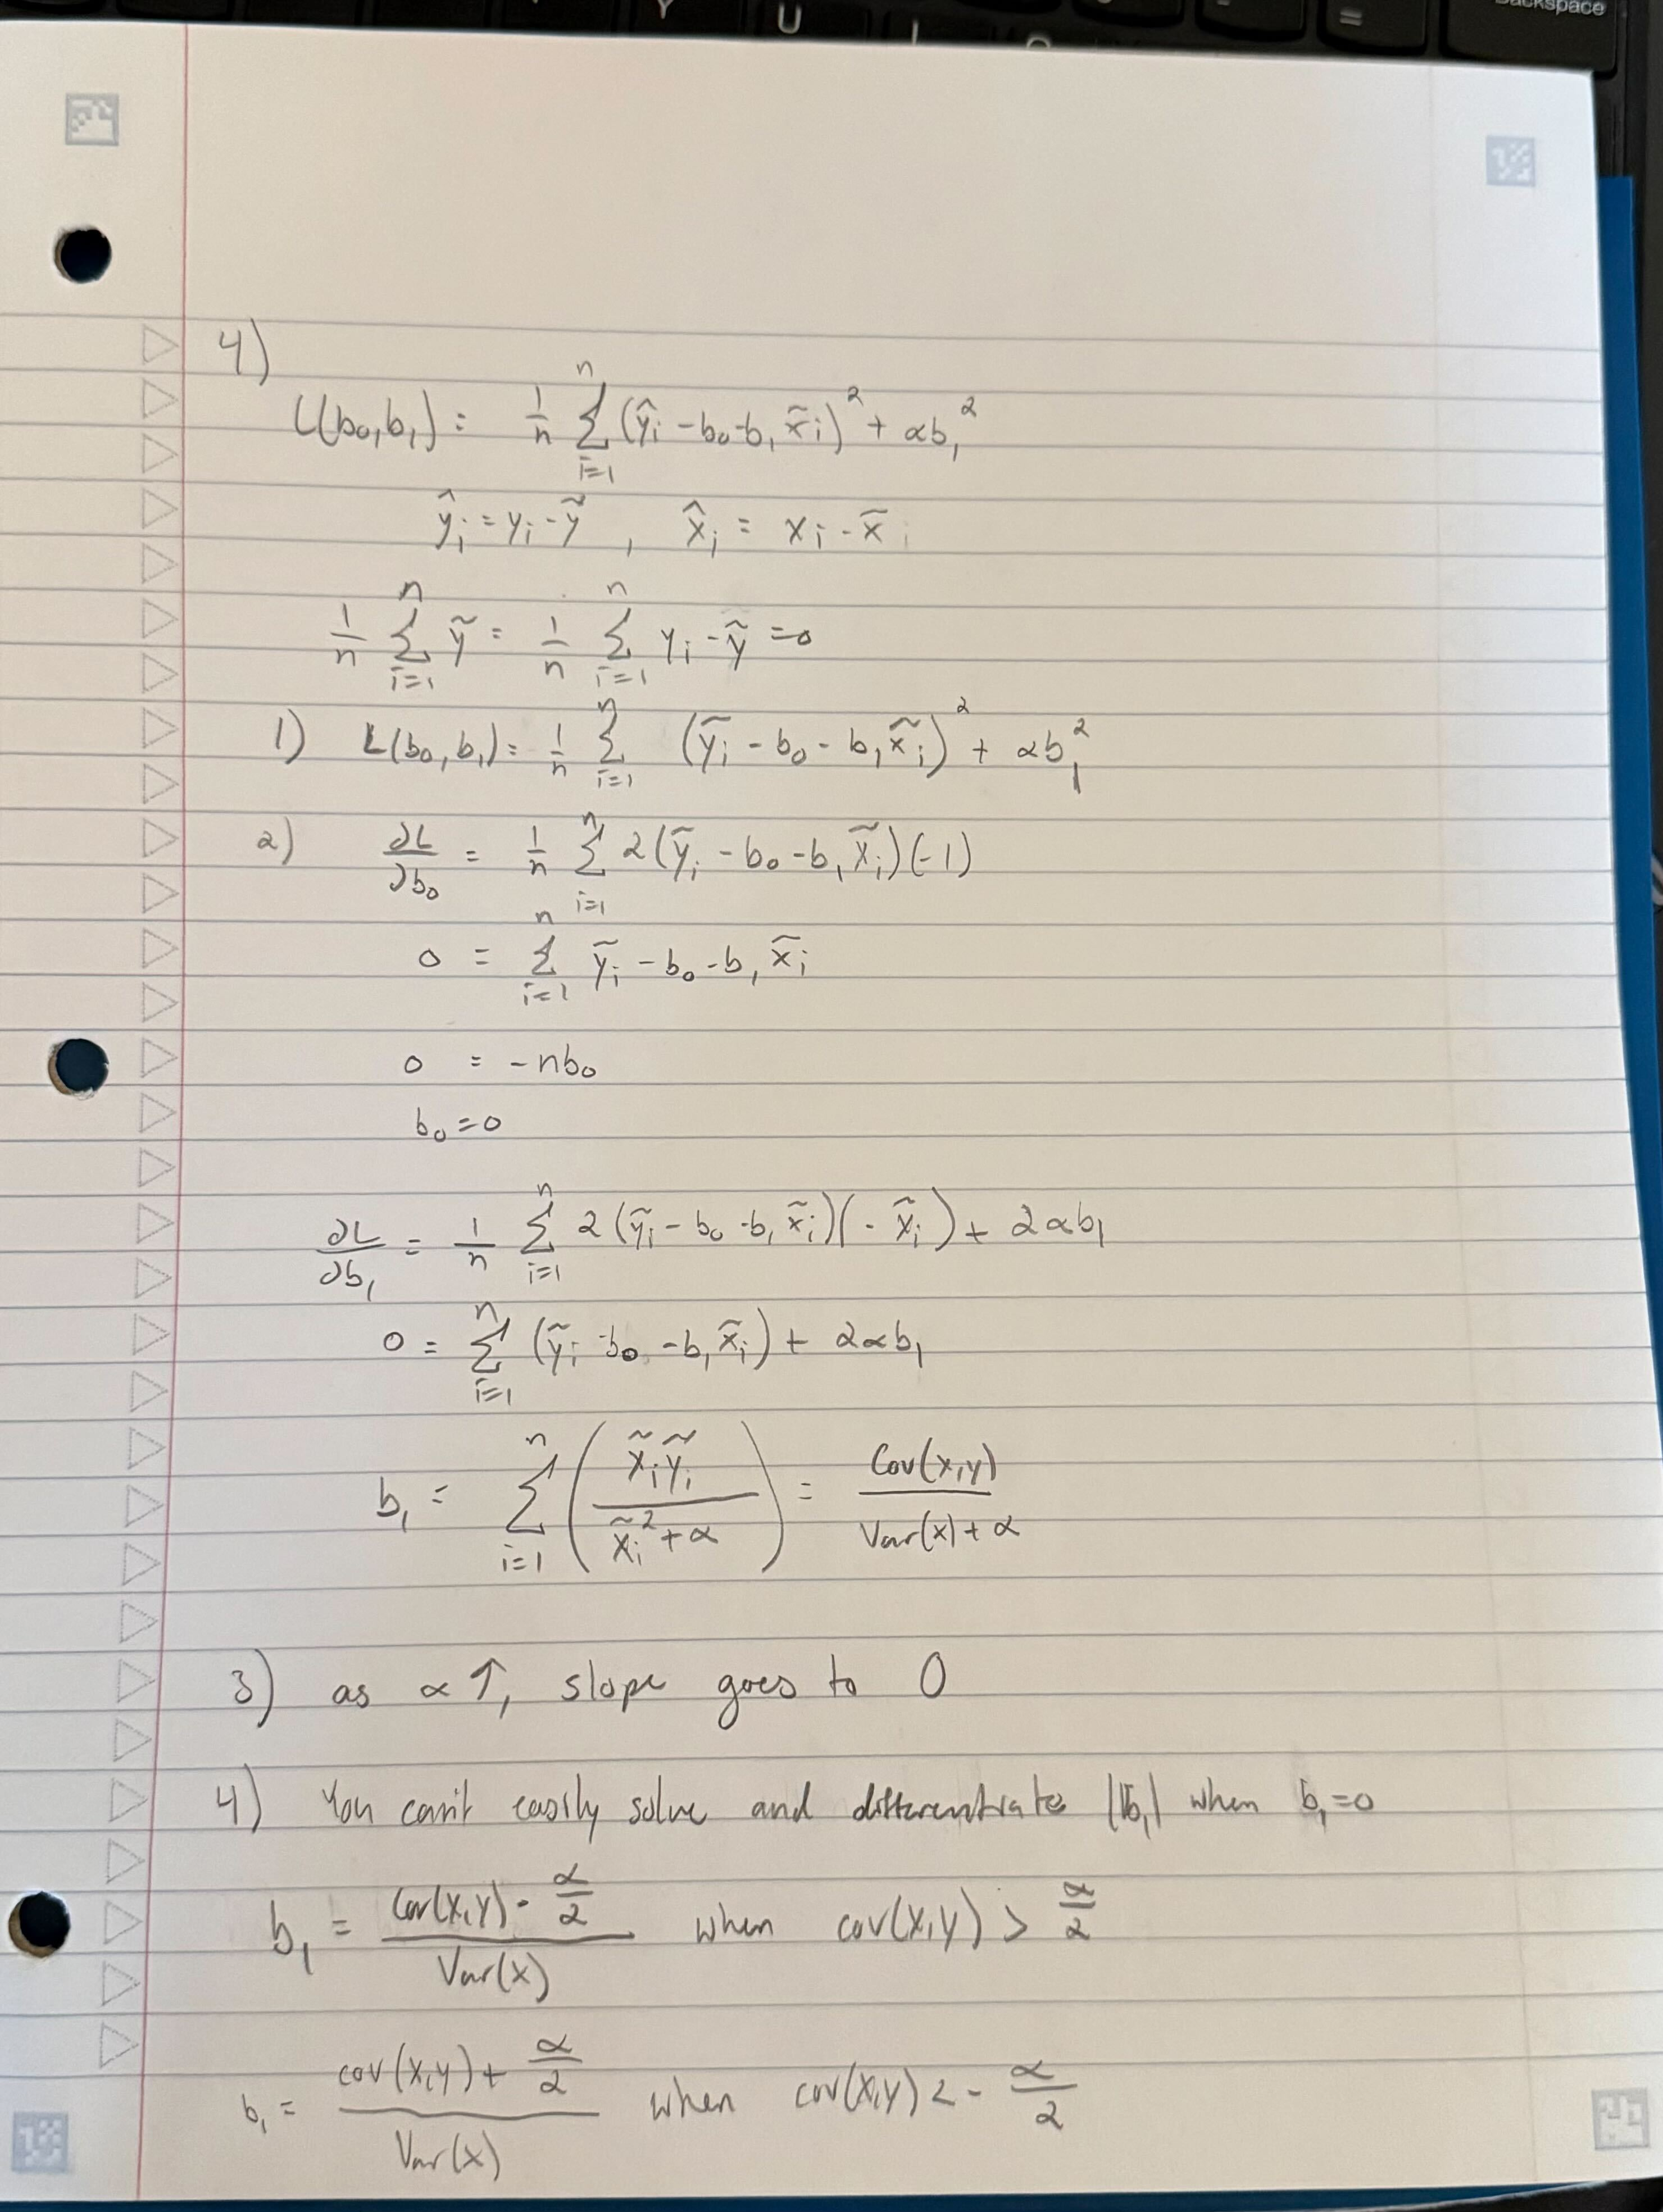